# 03 — Exploratory Genomic Analysis

Using the QC-filtered DArTseq SNP data to assess whether there is genuine biological signal:

1. **PCA** — population structure, outliers, batch effects
2. **Pairwise relatedness** — IBS-based kinship estimates
3. **Spatial analysis** — map samples, correlate genetic vs geographic distance (isolation by distance)
4. **Summary** — is there real signal for CKMR?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

DATA = Path("../data")

In [2]:
# Load filtered genotypes and metadata
geno_f = pd.read_csv(DATA / "geno_filtered.csv", index_col=0)
metadata = pd.read_csv(DATA / "master_metadata.csv")

# Deduplicate metadata on sample_id (keep first occurrence)
meta = metadata.drop_duplicates("sample_id").set_index("sample_id")

# Align: only samples in both genotype data and metadata
common = geno_f.columns.intersection(meta.index)
geno_f = geno_f[common]
meta = meta.loc[common]

print(f"Genotype matrix: {geno_f.shape[0]} markers × {geno_f.shape[1]} samples")
print(f"Metadata: {len(meta)} samples")
print(f"Missing rate: {geno_f.isna().mean().mean():.3f}")

Genotype matrix: 19930 markers × 835 samples
Metadata: 835 samples
Missing rate: 0.076


## 1. PCA — Population Structure

PCA on the genotype matrix (samples × markers). Missing values imputed with per-marker mean (allele frequency). Looking for:
- Outlier samples (contamination, wrong species)
- Batch effects (clustering by plate)
- Population structure (unexpected subgroups)

In [3]:
# Prepare matrix: samples × markers, impute missing with column mean
X = geno_f.T.values  # (n_samples, n_markers)
imputer = SimpleImputer(strategy="mean")
X_imp = imputer.fit_transform(X)

# Run PCA
pca = PCA(n_components=10)
pcs = pca.fit_transform(X_imp)
var_explained = pca.explained_variance_ratio_

print("Variance explained by top 10 PCs:")
for i, v in enumerate(var_explained):
    print(f"  PC{i+1}: {v:.4f} ({v*100:.2f}%)")
print(f"  Total (PC1-10): {sum(var_explained):.4f} ({sum(var_explained)*100:.2f}%)")

# Add to metadata
pc_df = pd.DataFrame(pcs, index=geno_f.columns, columns=[f"PC{i+1}" for i in range(10)])
meta_pca = meta.join(pc_df)

Variance explained by top 10 PCs:
  PC1: 0.0119 (1.19%)
  PC2: 0.0092 (0.92%)
  PC3: 0.0065 (0.65%)
  PC4: 0.0044 (0.44%)
  PC5: 0.0023 (0.23%)
  PC6: 0.0020 (0.20%)
  PC7: 0.0020 (0.20%)
  PC8: 0.0020 (0.20%)
  PC9: 0.0020 (0.20%)
  PC10: 0.0019 (0.19%)
  Total (PC1-10): 0.0441 (4.41%)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PC1 vs PC2, coloured by species
for sp, grp in meta_pca.groupby("morph_id"):
    label = sp.replace("anopheles_", "An. ") if pd.notna(sp) else "unknown"
    axes[0].scatter(grp["PC1"], grp["PC2"], alpha=0.5, s=15, label=label)
axes[0].set_xlabel(f"PC1 ({var_explained[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({var_explained[1]*100:.1f}%)")
axes[0].set_title("PCA coloured by species")
axes[0].legend(fontsize=8)

# PC1 vs PC2, coloured by plate (batch effect check)
plates = meta_pca["plate"].astype(str)
for plate, grp in meta_pca.groupby(plates):
    axes[1].scatter(grp["PC1"], grp["PC2"], alpha=0.4, s=15, label=f"Plate {plate}")
axes[1].set_xlabel(f"PC1 ({var_explained[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({var_explained[1]*100:.1f}%)")
axes[1].set_title("PCA coloured by plate")
axes[1].legend(fontsize=6, ncol=2)

# PC1 vs PC2, coloured by sex
for sex, grp in meta_pca.groupby("mosquito_sex"):
    axes[2].scatter(grp["PC1"], grp["PC2"], alpha=0.4, s=15, label=sex)
axes[2].set_xlabel(f"PC1 ({var_explained[0]*100:.1f}%)")
axes[2].set_ylabel(f"PC2 ({var_explained[1]*100:.1f}%)")
axes[2].set_title("PCA coloured by sex")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../results/fig_pca.png", bbox_inches="tight")
plt.show()

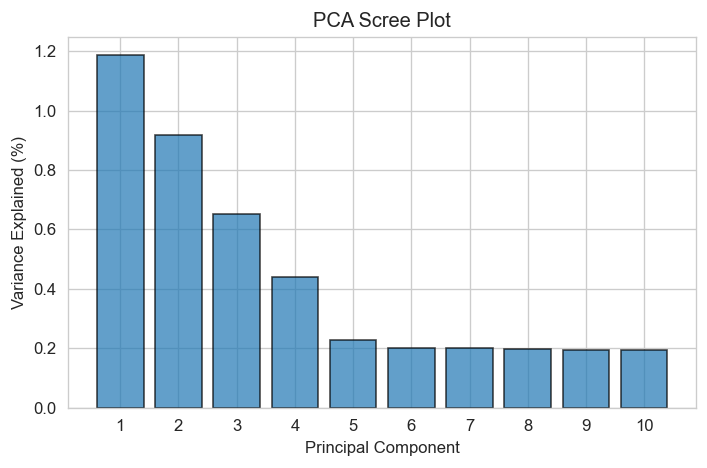

In [5]:
# Scree plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, 11), var_explained * 100, edgecolor="black", alpha=0.7)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Variance Explained (%)")
ax.set_title("PCA Scree Plot")
ax.set_xticks(range(1, 11))
plt.tight_layout()
plt.show()

## 2. Pairwise Relatedness (IBS)

Compute identity-by-state (IBS) similarity between all pairs of samples. IBS is the proportion of called loci where two samples share the same genotype. This is a simple proxy for relatedness — close kin (parent-offspring, full-sibs) will have higher IBS than unrelated individuals.

For computational efficiency, we use a random subset of markers if the full set is too large.

In [6]:
def compute_ibs_matrix(geno_df, max_markers=10000, seed=42):
    """Compute pairwise IBS (identity-by-state) similarity matrix (vectorized).
    
    IBS(i,j) = proportion of co-called loci where genotypes match.
    Uses matrix operations for speed.
    """
    rng = np.random.default_rng(seed)
    
    # Subsample markers if needed
    if geno_df.shape[0] > max_markers:
        idx = rng.choice(geno_df.shape[0], max_markers, replace=False)
        G = geno_df.iloc[idx].values.T.astype(float)  # (n_samples, n_markers)
        print(f"Subsampled to {max_markers} markers for IBS computation")
    else:
        G = geno_df.values.T.astype(float)
    
    n_samples, n_markers = G.shape
    print(f"Computing IBS for {n_samples} samples × {n_markers} markers...")
    
    # Mask: 1 where called, 0 where missing
    called = (~np.isnan(G)).astype(float)
    
    # Number of co-called loci per pair: called @ called.T
    n_cocalled = called @ called.T
    
    # For matching: replace NaN with a value that won't match anything
    G_filled = np.where(np.isnan(G), -999, G)
    
    # Count matches for each genotype value (0, 1, 2)
    n_matches = np.zeros((n_samples, n_samples))
    for val in [0, 1, 2]:
        indicator = (G_filled == val).astype(float)
        n_matches += indicator @ indicator.T
    
    # IBS = matches / co-called
    with np.errstate(divide='ignore', invalid='ignore'):
        ibs = n_matches / n_cocalled
        ibs[n_cocalled == 0] = np.nan
    
    return pd.DataFrame(ibs, index=geno_df.columns, columns=geno_df.columns)

ibs_mat = compute_ibs_matrix(geno_f, max_markers=10000)
print(f"IBS matrix: {ibs_mat.shape}")

# Distribution of off-diagonal IBS values
triu_idx = np.triu_indices(len(ibs_mat), k=1)
ibs_offdiag = ibs_mat.values[triu_idx]
print(f"\nPairwise IBS statistics ({len(ibs_offdiag)} pairs):")
print(f"  Mean: {np.nanmean(ibs_offdiag):.4f}")
print(f"  Std:  {np.nanstd(ibs_offdiag):.4f}")
print(f"  Min:  {np.nanmin(ibs_offdiag):.4f}")
print(f"  Max:  {np.nanmax(ibs_offdiag):.4f}")

Subsampled to 10000 markers for IBS computation
Computing IBS for 835 samples × 10000 markers...


IBS matrix: (835, 835)

Pairwise IBS statistics (348195 pairs):
  Mean: 0.8035
  Std:  0.0068
  Min:  0.7338
  Max:  0.9046


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of pairwise IBS
axes[0].hist(ibs_offdiag[~np.isnan(ibs_offdiag)], bins=100, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Pairwise IBS")
axes[0].set_ylabel("Number of pairs")
axes[0].set_title("Distribution of pairwise IBS")

# Highlight potential close kin (top 0.1% of IBS values)
threshold = np.nanpercentile(ibs_offdiag, 99.9)
axes[0].axvline(threshold, color="red", linestyle="--", label=f"99.9th percentile ({threshold:.4f})")
axes[0].legend()

# Heatmap of IBS matrix (subsample if too large)
n_show = min(100, len(ibs_mat))
ibs_sub = ibs_mat.iloc[:n_show, :n_show]
im = axes[1].imshow(ibs_sub.values, cmap="viridis", aspect="auto")
axes[1].set_title(f"IBS heatmap (first {n_show} samples)")
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("Sample")
plt.colorbar(im, ax=axes[1], label="IBS")

plt.tight_layout()
plt.savefig("../results/fig_ibs.png", bbox_inches="tight")
plt.show()

# Top most-related pairs
n_top = 20
pair_idx = np.argsort(ibs_offdiag)[::-1][:n_top]
print(f"\nTop {n_top} most related pairs (by IBS):")
samples = ibs_mat.index
for rank, idx in enumerate(pair_idx):
    i, j = triu_idx[0][idx], triu_idx[1][idx]
    s1, s2 = samples[i], samples[j]
    sp1 = meta.loc[s1, "morph_id"] if s1 in meta.index else "?"
    sp2 = meta.loc[s2, "morph_id"] if s2 in meta.index else "?"
    print(f"  {rank+1}. {s1} ({sp1}) — {s2} ({sp2}): IBS={ibs_offdiag[idx]:.4f}")

## 3. Spatial Analysis — Isolation by Distance

Do genetically similar mosquitoes tend to be geographically closer? This is the core question for CKMR dispersal estimation.

We compute:
- Geographic distance (km) between all pairs with GPS
- Genetic distance (1 - IBS) between the same pairs
- Test for correlation (Mantel-like: Pearson r between distance matrices)

In [8]:
# Get samples with both GPS and IBS data
meta_gps = meta.dropna(subset=["latitude", "longitude"])
common_gps = meta_gps.index.intersection(ibs_mat.index)
print(f"Samples with both GPS and IBS: {len(common_gps)}")

coords = meta_gps.loc[common_gps, ["latitude", "longitude"]].values

# Geographic distance in km (Haversine)
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

n = len(common_gps)
geo_dist = np.zeros((n, n))
for i in range(n):
    for j in range(i+1, n):
        d = haversine_km(coords[i,0], coords[i,1], coords[j,0], coords[j,1])
        geo_dist[i,j] = geo_dist[j,i] = d

# Genetic distance (1 - IBS) for the same samples
ibs_sub = ibs_mat.loc[common_gps, common_gps].values
gen_dist = 1 - ibs_sub

# Extract upper triangle
triu = np.triu_indices(n, k=1)
geo_flat = geo_dist[triu]
gen_flat = gen_dist[triu]

# Remove pairs with NaN
valid = ~np.isnan(gen_flat) & ~np.isnan(geo_flat)
geo_valid = geo_flat[valid]
gen_valid = gen_flat[valid]

r, p = pearsonr(geo_valid, gen_valid)
print(f"\nIsolation by distance:")
print(f"  Pearson r = {r:.4f}, p = {p:.2e}")
print(f"  Valid pairs: {valid.sum()}")
print(f"  Geographic distance range: {geo_valid.min():.3f} – {geo_valid.max():.3f} km")

Samples with both GPS and IBS: 835



Isolation by distance:
  Pearson r = -0.0167, p = 6.19e-23
  Valid pairs: 348195
  Geographic distance range: 0.000 – 5.279 km


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# IBD scatter plot
axes[0].scatter(geo_valid, gen_valid, alpha=0.01, s=1, color="steelblue")
axes[0].set_xlabel("Geographic distance (km)")
axes[0].set_ylabel("Genetic distance (1 - IBS)")
axes[0].set_title(f"Isolation by distance (r={r:.4f}, p={p:.2e})")

# Binned means for clearer trend
n_bins = 20
bins = np.linspace(geo_valid.min(), geo_valid.max(), n_bins + 1)
bin_centers = []
bin_means = []
bin_sems = []
for b in range(n_bins):
    mask = (geo_valid >= bins[b]) & (geo_valid < bins[b+1])
    if mask.sum() > 10:
        bin_centers.append((bins[b] + bins[b+1]) / 2)
        bin_means.append(gen_valid[mask].mean())
        bin_sems.append(gen_valid[mask].std() / np.sqrt(mask.sum()))

axes[1].errorbar(bin_centers, bin_means, yerr=bin_sems, fmt="o-", capsize=3, 
                  color="steelblue", markersize=5)
axes[1].set_xlabel("Geographic distance (km)")
axes[1].set_ylabel("Mean genetic distance (1 - IBS)")
axes[1].set_title("Binned isolation by distance")

# Map of sample locations
has_gps = meta.dropna(subset=["latitude", "longitude"])
axes[2].scatter(has_gps["longitude"], has_gps["latitude"], 
                alpha=0.4, s=10, c="steelblue")
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")
axes[2].set_title(f"Sample locations ({len(has_gps)} samples)")
axes[2].set_aspect("equal")

plt.tight_layout()
plt.savefig("../results/fig_spatial.png", bbox_inches="tight")
plt.show()

## 4. Close kin — are the most related pairs geographically close?

In [10]:
# For top related pairs, compute geographic distance
top_n = 50
ibs_gps = ibs_mat.loc[common_gps, common_gps]
triu_gps = np.triu_indices(len(common_gps), k=1)
ibs_gps_flat = ibs_gps.values[triu_gps]
geo_gps_flat = geo_dist[triu_gps]

# Sort by IBS (highest = most related)
order = np.argsort(ibs_gps_flat)[::-1]

print(f"Top {top_n} most related pairs — IBS and geographic distance:")
print(f"{'Rank':<5} {'Sample1':<18} {'Sample2':<18} {'IBS':>8} {'Dist(km)':>10}")
print("-" * 60)
for rank in range(top_n):
    idx = order[rank]
    i, j = triu_gps[0][idx], triu_gps[1][idx]
    s1 = common_gps[i]
    s2 = common_gps[j]
    print(f"{rank+1:<5} {s1:<18} {s2:<18} {ibs_gps_flat[idx]:>8.4f} {geo_gps_flat[idx]:>10.3f}")

# Compare: geographic distance of top 50 pairs vs random 50 pairs
top_geo = geo_gps_flat[order[:top_n]]
rng = np.random.default_rng(42)
rand_idx = rng.choice(len(ibs_gps_flat), top_n, replace=False)
rand_geo = geo_gps_flat[rand_idx]

print(f"\nGeographic distance comparison:")
print(f"  Top {top_n} related pairs: mean={np.mean(top_geo):.3f} km, median={np.median(top_geo):.3f} km")
print(f"  Random {top_n} pairs:      mean={np.mean(rand_geo):.3f} km, median={np.median(rand_geo):.3f} km")

Top 50 most related pairs — IBS and geographic distance:
Rank  Sample1            Sample2                 IBS   Dist(km)
------------------------------------------------------------
1     ep0000915423       ep0000916899         0.9046      1.193
2     ep0000915455       ep0000846123         0.8809      0.556
3     ep0000915332       ep0000914830         0.8803      0.711
4     ep0000917698       ep0000915794         0.8739      0.789
5     ep0000911512       ep0000841747         0.8300      1.978
6     ep0000923584       ep0000844425         0.8298      1.894
7     ep0000911512       ep0000844425         0.8297      3.335
8     ep0000911512       ep0000915234         0.8287      2.120
9     ep0000911512       ep0000842479         0.8284      2.467
10    ep0000911512       ep0000922608         0.8282      1.578
11    ep0000917012       ep0000844425         0.8280      0.968
12    ep0000915234       ep0000842479         0.8278      1.247
13    ep0000911512       ep0000911965         0.82

## 5. Summary

In [11]:
print("=" * 60)
print("DATASET ASSESSMENT SUMMARY")
print("=" * 60)

print(f"""
SAMPLES:
  Total in ODK: 994 mosquitoes
  In genomic data: 894
  After QC filtering (CR >= 0.5): 836
  With GPS coordinates: {meta.dropna(subset=['latitude', 'longitude']).shape[0]}

MARKERS (SNP):
  Total SNP loci: 114,038
  After QC (CR>=0.7, MAF>=0.01, Rep>=0.95): {geno_f.shape[0]:,}
  Missingness in filtered data: {geno_f.isna().mean().mean():.1%}

PCA:
  PC1 explains {var_explained[0]*100:.1f}% of variance
  Top 10 PCs explain {sum(var_explained)*100:.1f}%

RELATEDNESS:
  Mean pairwise IBS: {np.nanmean(ibs_offdiag):.4f}
  Max pairwise IBS: {np.nanmax(ibs_offdiag):.4f}
  99.9th percentile: {np.nanpercentile(ibs_offdiag, 99.9):.4f}

ISOLATION BY DISTANCE:
  Pearson r = {r:.4f}, p = {p:.2e}
  Geographic range: {geo_valid.min():.3f} – {geo_valid.max():.3f} km
""")

DATASET ASSESSMENT SUMMARY

SAMPLES:
  Total in ODK: 994 mosquitoes
  In genomic data: 894
  After QC filtering (CR >= 0.5): 836
  With GPS coordinates: 835

MARKERS (SNP):
  Total SNP loci: 114,038
  After QC (CR>=0.7, MAF>=0.01, Rep>=0.95): 19,930
  Missingness in filtered data: 7.6%

PCA:
  PC1 explains 1.2% of variance
  Top 10 PCs explain 4.4%

RELATEDNESS:
  Mean pairwise IBS: 0.8035
  Max pairwise IBS: 0.9046
  99.9th percentile: 0.8215

ISOLATION BY DISTANCE:
  Pearson r = -0.0167, p = 6.19e-23
  Geographic range: 0.000 – 5.279 km

